# Analyse biochemical properties of isopeptide bond PDB/AF2 datasets

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
from biotite.structure.io import pdb
import biotite.structure as struc
import shutil
import sys
sys.path.append("../bin")
from sequence import get_sequence

In [2]:
load_dotenv("../.env")
PDB_BIOCHEM = os.getenv("PDB_BIOCHEM")
AF2_BIOCHEM = os.getenv("AF2_BIOCHEM")
AF2_TEMPLATES_BIOCHEM = os.getenv("AF2_TEMPLATES_BIOCHEM")
TABLE = os.getenv("TABLE")

In [3]:
pdb_df = pd.read_csv(PDB_BIOCHEM)
af_df = pd.read_csv(AF2_BIOCHEM)
af_templates_df = pd.read_csv(AF2_TEMPLATES_BIOCHEM)
table_df = pd.read_csv(TABLE)

# Get isopep sequence (between bonded residues)
pdb_df["isopep_sequence"] = pdb_df.apply(get_sequence, pdb=True, axis=1)
af_df["isopep_sequence"] = af_df.apply(get_sequence, pdb=False, axis=1)
af_templates_df["isopep_sequence"] = af_templates_df.apply(get_sequence, pdb=False, axis=1)

## Pfam domain mapping

In [46]:
import sys
sys.path.append("../bin")
from pfamenv import PFAM_HOST,PFAM_PASSWORD,PFAM_PORT,PFAM_USER,PFAM_VERSION
from mysql import connector
import numpy as np

def is_domain(row):
    """

        Assign if at least 2/3 residues are in domain
    
    """
    residues = [row["r1_bond"], row["r_cat"], row["r2_bond"]]
    status = False
    c = 0
    for res in residues:
        if res >= row["seq_start"] and res <= row["seq_end"]:
            c += 1
            #status = True
            #break
    if c >= 2:
        status = True
    return status

In [47]:
# Get pfam info associated with each PDB
columns = ["pdb_id", "pfamA_acc", "pfamA_id", "chain", "pdb_res_start", "pdb_res_end", "seq_start", "seq_end", "clan_acc", "clan_id"]

proteins = pdb_df[(pdb_df["Is bonded"])&(~pdb_df["Interchain"])&(pdb_df["Isopeptide type"]!="Mutant")]["PDB code"].unique()

cnx = connector.connect(user=PFAM_USER,
                        password=PFAM_PASSWORD,
                        port=PFAM_PORT,
                        host=PFAM_HOST)
cursor = cnx.cursor()

proteins_ = ", ".join([f"'{protein}'" for protein in proteins])

# Get domains
cursor.execute(f"SELECT pdb_id,pfamA.pfamA_acc,pfamA.pfamA_id,chain,pdb_res_start,pdb_res_end,seq_start,seq_end,\
                    clan_membership.clan_acc,clan.clan_id \
                 FROM {PFAM_VERSION}.pdb_pfamA_reg, {PFAM_VERSION}.pfamA, \
                     {PFAM_VERSION}.clan_membership, {PFAM_VERSION}.clan \
                 WHERE pdb_id IN ({proteins_}) \
                 AND pfamA.pfamA_acc = clan_membership.pfamA_acc \
                 AND clan.clan_acc=clan_membership.clan_acc \
                 AND pfamA.pfamA_acc = pdb_pfamA_reg.pfamA_acc")
output = cursor.fetchall()
d_df = pd.DataFrame(output, columns = columns)
d_df["pdb_id"] = d_df["pdb_id"].apply(lambda x: x.lower())
data_df = pd.merge(pdb_df, d_df.rename(columns={"pdb_id":"PDB code", "chain":"Chain"}), how="left")\
        .rename(columns={"Position 1\r\n(Bond 1)":"r1_bond", "Position 2\r\n(catalytic)":"r_cat", "Position 3\r\n(Bond 2)":"r2_bond"})

# Check which domains map to isopep bonds
data_df["is_domain"] = data_df.apply(lambda x: is_domain(x), axis=1)
data_df = data_df.sort_values("is_domain", ascending=False) \
        .drop_duplicates(["PDB code", "r1_bond", "r_cat", "r2_bond"], keep="first")
data_df.loc[data_df["is_domain"]==False, "pfamA_acc"] = np.NaN
data_df.loc[data_df["is_domain"]==False, "pfamA_id"] = np.NaN
data_df.loc[data_df["is_domain"]==False, "seq_start"] = np.NaN
data_df.loc[data_df["is_domain"]==False, "seq_end"] = np.NaN
data_df["seq_start"] = data_df["seq_start"].fillna(0).astype(int)
data_df["seq_end"] = data_df["seq_end"].fillna(0).astype(int)
data_df["residues"] = data_df.apply(lambda x: ", ".join([str(_) for _ in [x["r1_bond"], x["r_cat"], x["r2_bond"]]]), axis=1)
data_df["PDB code"] = data_df["PDB code"].apply(lambda x: x.upper())

In [64]:
data_df[["pfamA_id", "pfamA_acc", "clan_id", "PDB code", "Chain", "seq_start", "seq_end", "residues"]]\
.drop_duplicates("pfamA_id").set_index("pfamA_id").sort_values("clan_id")

,pfamA_acc,clan_id,PDB code,Chain,seq_start,seq_end,residues
pfamA_id,,,,,,,
AgI_II_C2,PF17998,Adhesin,5DZ9,A,554,723,"556, 606, 703"
Sgo0707_N2,PF20623,Adhesin,4HSS,A,178,324,"187, 224, 299"
GramPos_pilinBB,PF16569,Adhesin,2X9Z,A,216,328,"193, 241, 318"
Collagen_bind,PF05737,Adhesin,7LGR,A,173,306,"177, 210, 291"
Antigen_C,PF16364,Adhesin,3OPU,A,1334,1492,"1334, 1383, 1469"
GBS104-like_Ig,PF21426,E-set,3TXA,A,587,717,"188, 597, 692"
DUF5979,PF19407,Transthyretin,4BUG,A,606,718,"610, 680, 715"
SpaA,PF17802,Transthyretin,2XID,A,291,377,"297, 347, 595"
GramPos_pilinD3,PF16570,Transthyretin,2X9Z,A,388,448,"349, 405, 428"


In [19]:
data_df["pfamA_id"].unique()

array(['DUF5979', 'AgI_II_C2', 'SpaA', 'Sgo0707_N2', 'GramPos_pilinBB',
       'GramPos_pilinD3', 'Collagen_bind', 'FctA', 'GramPos_pilinD1',
       'Antigen_C', 'GBS104-like_Ig', 'Cna_B', nan], dtype=object)

## Correlations

In [4]:
cond1 = (pdb_df["Is bonded"])
cond2 = (pdb_df["Isopeptide type"]!="Mutant")
cond3 = (~pdb_df["Unusual geometry/chemistry"])
cond4 = (pdb_df["Resolution"]<=2.5)
cond5 = (~pdb_df["Bad rotamer"])
cor_df = pdb_df[cond1&cond2&cond3&cond4&cond5].drop_duplicates("isopep_sequence").copy()

/tmp/ipykernel_1321084/2996964384.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .assign(isopep_type=lambda x: x["isopep_type"].replace({"CnaA-like":0, "CnaB-like":1})) \
/tmp/ipykernel_1321084/2996964384.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .assign(res_3=lambda x: x["res_3"].replace({"N":1, "D":0})) \


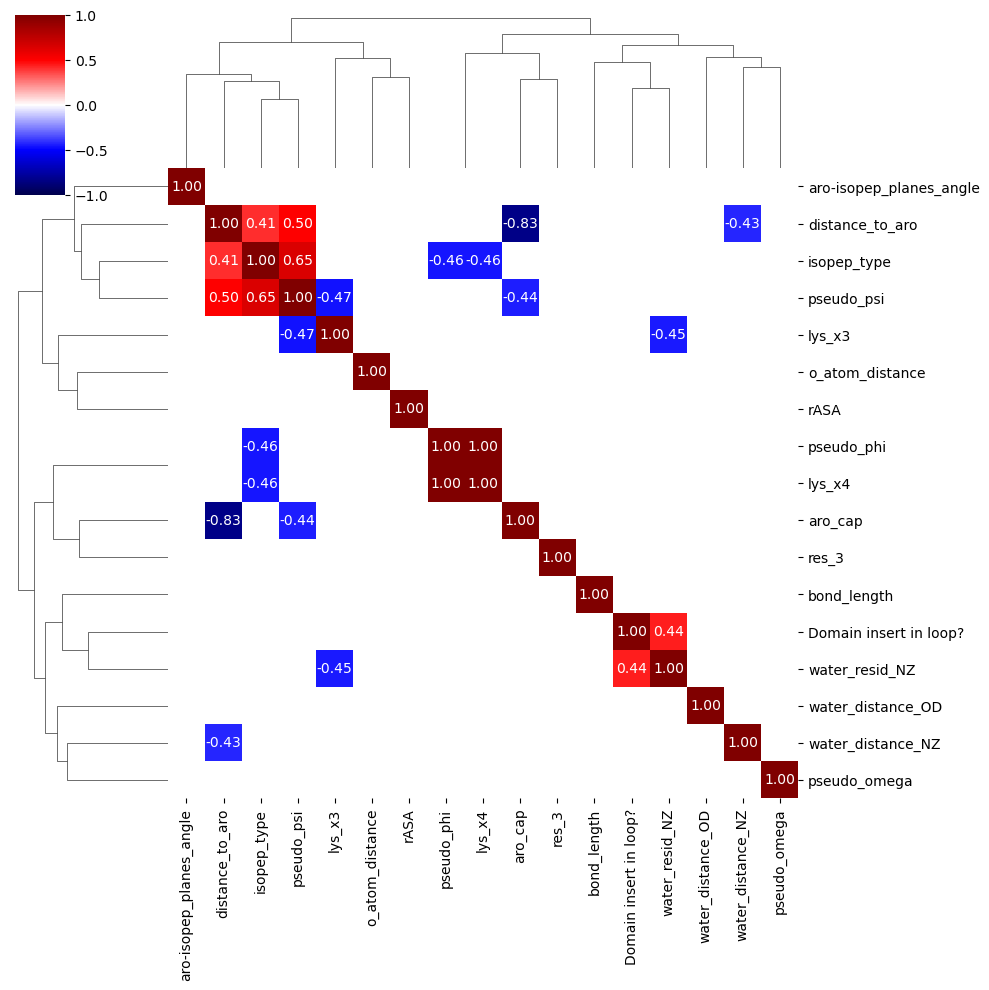

In [5]:
corr_matrix = cor_df[
    ['Isopeptide type', 'Domain insert in loop?',
       'distance_to_aro', 'aro-isopep_planes_angle', 'aro_cap',
       'water_resid_NZ', 'water_distance_NZ',
       'water_distance_OD',
       'o_atom_distance', 'rASA', 'bond_length', 'pseudo_omega', 'pseudo_psi',
       'pseudo_phi', 'lys_x3', 'lys_x4', 'Residue 3']
    ].rename(columns={"Isopeptide type":"isopep_type", "Residue 3":"res_3"})\
    .assign(isopep_type=lambda x: x["isopep_type"].replace({"CnaA-like":0, "CnaB-like":1})) \
    .assign(res_3=lambda x: x["res_3"].replace({"N":1, "D":0})) \
    .assign(rASA=lambda x: x["rASA"].apply(lambda y: np.mean(eval(y)))) \
    .corr()

threshold = .4
mask = np.abs(corr_matrix) < threshold
sns.clustermap(corr_matrix, cmap="seismic", vmin=-1, vmax=1, annot=True, fmt=".2f", mask=mask)

## Aromatic residues

In [4]:
cond1 = (pdb_df["Is bonded"])
cond2 = (pdb_df["Isopeptide type"]!="Mutant")
cond3 = (~pdb_df["Unusual geometry/chemistry"])
cond4 = (pdb_df["Resolution"]<=2.5)
cond5 = (~pdb_df["Bad rotamer"])
aro_df = pdb_df[cond1&cond2&cond3&cond4&cond5].sort_values("aro_cap", ascending=False).drop_duplicates("isopep_sequence")

In [5]:
# 
aro_df.groupby("Isopeptide type")["aro_cap"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,Isopeptide type,aro_cap,percentage
0,CnaA-like,True,84.0
1,CnaA-like,False,16.0
2,CnaB-like,False,65.0
3,CnaB-like,True,35.0


## Properties

In [6]:
cond1 = pdb_df["Is bonded"]
cond2 = ~pdb_df["Bad rotamer"]
cond3 = ~pdb_df["Unusual geometry/chemistry"]
cond4 = pdb_df["Isopeptide type"] != "Mutant"
cond5 = pdb_df["Resolution"] <= 2.5
analysis_df = pdb_df[cond1 & cond2 & cond3 & cond4 & cond5].drop_duplicates("isopep_sequence").copy()

In [9]:
analysis_df.fillna("nd").groupby("cis_trans")["aro_cap"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,cis_trans,aro_cap,percentage
0,cis,True,94.0
1,cis,False,6.0
2,nd,True,50.0
3,nd,False,50.0
4,trans,False,76.0
5,trans,True,24.0


In [10]:
analysis_df[analysis_df["Residue 3"]=="N"].fillna("nd").groupby("cis_trans")["aro_cap"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,cis_trans,aro_cap,percentage
0,cis,True,94.0
1,cis,False,6.0
2,nd,True,67.0
3,nd,False,33.0
4,trans,False,71.0
5,trans,True,29.0


In [12]:
analysis_df[analysis_df["Residue 3"]=="D"].fillna("nd").groupby("cis_trans")["aro_cap"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,cis_trans,aro_cap,percentage
0,nd,False,100.0
1,trans,False,100.0


In [11]:
# Vs lys/asp
analysis_df[analysis_df["Residue 3"]=="N"] \
    .fillna("nd").value_counts("cis_trans", normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round(2)

,cis_trans,percentage
0,cis,49.50
1,trans,47.52
2,nd,2.97


In [11]:
# Vs lys/asp
analysis_df.fillna("nd").groupby("Residue 3")["cis_trans"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index()

,Residue 3,cis_trans,percentage
0,D,trans,90.909091
1,D,nd,9.090909
2,N,cis,49.504950
3,N,trans,47.524752
4,N,nd,2.970297


In [12]:
#
analysis_df.fillna("nd").groupby("Isopeptide type")["cis_trans"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,Isopeptide type,cis_trans,percentage
0,CnaA-like,cis,67.0
1,CnaA-like,trans,31.0
2,CnaA-like,nd,2.0
3,CnaB-like,trans,68.0
4,CnaB-like,cis,27.0
5,CnaB-like,nd,5.0


In [13]:
analysis_df.groupby("Isopeptide type")["cis_trans"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,Isopeptide type,cis_trans,percentage
0,CnaA-like,cis,69.0
1,CnaA-like,trans,31.0
2,CnaB-like,trans,72.0
3,CnaB-like,cis,28.0


In [14]:
analysis_df.groupby("Domain insert in loop?")["cis_trans"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,Domain insert in loop?,cis_trans,percentage
0,False,cis,51.0
1,False,trans,49.0
2,True,trans,100.0


In [15]:
analysis_df.fillna("nd").groupby("aro_cap")["cis_trans"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,aro_cap,cis_trans,percentage
0,False,trans,90.0
1,False,cis,6.0
2,False,nd,4.0
3,True,cis,75.0
4,True,trans,22.0
5,True,nd,3.0


In [16]:
analysis_df[analysis_df["Residue 3"]=="N"].fillna("nd").groupby("cis_trans")["aro_cap"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,cis_trans,aro_cap,percentage
0,cis,True,94.0
1,cis,False,6.0
2,nd,True,67.0
3,nd,False,33.0
4,trans,False,71.0
5,trans,True,29.0


In [19]:
analysis_df[analysis_df["Residue 3"]=="D"].fillna("nd").groupby("cis_trans")["aro_cap"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,cis_trans,aro_cap,percentage
0,nd,False,100.0
1,trans,False,100.0


In [18]:
analysis_df.groupby("Domain insert in loop?")["cis_trans"] \
    .value_counts(normalize=False)

Domain insert in loop?  cis_trans
False                   cis          50
                        trans        49
True                    trans         9
Name: count, dtype: int64

## Proximal oxygen

In [21]:
cond1 = pdb_df["Is bonded"]
cond2 = ~pdb_df["Bad rotamer"]
cond3 = ~pdb_df["Unusual geometry/chemistry"]
cond4 = pdb_df["Isopeptide type"] != "Mutant"
cond5 = pdb_df["Resolution"] <= 2.5

o_df = pdb_df[cond1 & cond2 & cond3 & cond4 & cond5] \
        .drop_duplicates("isopep_sequence").copy()

o_df["water_od"] = False
o_df.loc[o_df["water_distance_OD"] <= 5, "water_od"] = True

o_df["any_ox"] = False
o_df.loc[o_df["o_atom_distance"] <= 5, "any_ox"] = True

In [22]:
o_df[o_df["Isopeptide type"]=="CnaA-like"].value_counts("water_od", normalize=True).round(2)

water_od
True     0.59
False    0.41
Name: proportion, dtype: float64

In [23]:
o_df[o_df["Isopeptide type"]=="CnaB-like"].value_counts("water_od", normalize=True).round(2)

water_od
True     0.54
False    0.46
Name: proportion, dtype: float64

In [24]:
o_df[o_df["Isopeptide type"]=="CnaA-like"].value_counts("any_ox", normalize=True).round(2)

any_ox
True    1.0
Name: proportion, dtype: float64

In [25]:
o_df[o_df["Isopeptide type"]=="CnaB-like"].value_counts("any_ox", normalize=True).round(2)

any_ox
True    1.0
Name: proportion, dtype: float64

In [26]:
# correlation with aro cap
o_df.groupby("aro_cap")["water_od"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,aro_cap,water_od,percentage
0,False,True,58.0
1,False,False,42.0
2,True,True,54.0
3,True,False,46.0


In [27]:
o_df[o_df["Isopeptide type"]=="CnaB-like"].groupby("aro_cap")["water_od"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,aro_cap,water_od,percentage
0,False,True,60.0
1,False,False,40.0
2,True,False,61.0
3,True,True,39.0


In [28]:
o_df[o_df["Isopeptide type"]=="CnaA-like"].groupby("aro_cap")["water_od"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .rename("percentage") \
    .reset_index().round()

,aro_cap,water_od,percentage
0,False,True,53.0
1,False,False,47.0
2,True,True,62.0
3,True,False,38.0


In [29]:
o_df.value_counts(["Residue 3", "water_od"])

Residue 3  water_od
N          True        59
           False       42
D          False        7
           True         4
Name: count, dtype: int64

In [30]:
o_df[o_df["Isopeptide type"]=="CnaB-like"].value_counts("any_ox", normalize=True).round(2)

any_ox
True    1.0
Name: proportion, dtype: float64

In [31]:
o_df[o_df["Isopeptide type"]=="CnaA-like"].value_counts("any_ox", normalize=True).round(2)

any_ox
True    1.0
Name: proportion, dtype: float64

In [32]:
o_df.value_counts(["Residue 3", "water_od"])

Residue 3  water_od
N          True        59
           False       42
D          False        7
           True         4
Name: count, dtype: int64

In [33]:
o_df.value_counts(["Residue 2"])

Residue 2
E            62
D            50
Name: count, dtype: int64